# La calibrazione di un rivelatore e il test di Fisher-Snedecor

Un rivelatore produce un impulso di tensione la cui ampiezza $V$ viene misurata in funzione dell'energia $E$ depositata nel suo volume sensibile.
Per tradurre un segnale misurato in energia depositata, si costruisce una curva di calibrazione
$$
\begin{align}
 E = \varphi(V, \underline{\theta})
\end{align}
$$
che, da un valore $V$ osservato, permette di ricavare l'energia $E$ associata alla misura.

La funzione $\varphi$ e i suoi parametri $\underline{\theta}$ vengono determinati a partire da un insieme di misure di calibrazione $(V_i, E_i)_{i=1\dots n}$ effettuate con energia nota.
Molto spesso la scelta per $\varphi$ ricade su un polinomio ed \`e importante decidere quale sia il suo grado massimo,
prima di fare il fit delle misure di calibrazione: se il grado \`e troppo basso, la funzione di calibrazione non descrive appropriatamente i dati e il fit \`e caratterizzato da un valore dello scarto quadratico medio $\hat{Q}^2$ molto elevato, mentre se il grado \`e troppo alto la funzione si adatta troppo alle loro fluttuazioni statistiche e il fit produce un valore di $\hat{Q}^2$ molto piccolo.

Siano due diverse funzioni di calibrazione $\varphi_1(V,\underline{\theta}_1)$ e $\varphi_2(,\underline{\theta}_2)$, con numero di parametri $p_1$ e $p_2$ rispettivamente, tali per cui $p_1 < p_2$ (ad esempio, $\varphi_1$ \`e una retta e $\varphi_2$ una parabola). Siano $\hat{Q}^2_1$ e $\hat{Q}^2_2$ gli scarti quadratici risultanti dal fit di ciascuna funzione  agli $n$ punti del campione di calibrazione.
Se i due modelli descrivono altrettanto bene i dati si dimonstra che in presenza di incertezze Gaussiane la variabile seguente:
$$
\begin{align}
\hat{\Phi} = \frac{\frac{\hat{Q}^2_1-\hat{Q}^2_2}{p_2-p_1}}{\frac{\hat{Q}^2_2}{n-p_2}} = \frac{\hat{Q}^2_2-\hat{Q}^2_1}{\hat{Q}^2_2}\cdot\frac{n-p_2}{p_2-p_1}
\end{align}
$$
segue la distribuzione di Fisher-Snedecor $F$, mentre assume valori in media maggiori nel caso in cui il modello $\varphi_2$ descriva meglio il campione, perch\'e al numeratore risulta una differenza  $\hat{Q}^2_1-\hat{Q}^2_2$ pi\`u importante.


Nota $F$, che \`e disponibile nelle librerie \texttt{scipy} si pu\`o definire un \textit{p-value} $\pi$ di compatibili\`a come:
$$
\begin{align}
\pi = \int_{\hat{\Phi}}^{+\infty} F(x)~dx~,
\end{align}
$$
dove $\hat{\Phi}$ \`e il valore della variabile ottenuto confrontando due modelli specifici.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from lib import rand_TCL_ms

## Punto 1

Assumendo che la relazione vera che lega $V$ ed $E$ sia $\varphi(V) = aV^2 + bV + c$, con:
$$
      \begin{align}
      \begin{cases}
      a = 1\\
      b = 2\\
      c = 2
      \end{cases}
      \end{align}
$$
si costruisca un campione di calibrazione $(V_i, E_i)_{i=1\dots 5}$, con i valori di $V_i$ compresi fra 1 e 5 equidistanziati e incertezza Gaussiana su $E_i$ = 0.25. 
Si disegni il campione di calibrazione nel piano $(V,E)$,  visualizzando anche l'incertezza di ciascun punto.

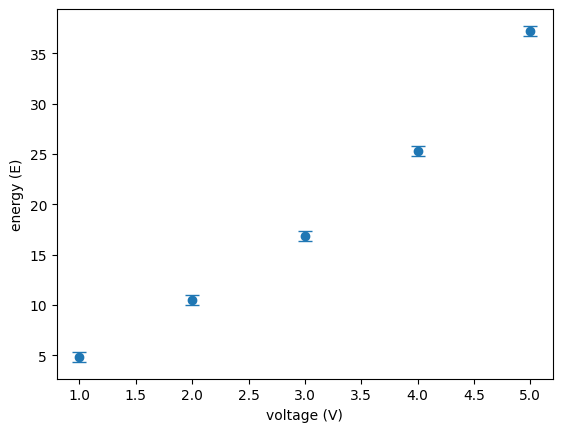

In [2]:
a = 1.
b = 2.
c = 2.
sigma = 0.5
N_points = 5

true_model = lambda V : a * V**2 + b * V + c
calib_V = np.linspace (1, 5, N_points)
calib_E = [true_model (V) for V in calib_V] # senza incertezze
calib_E = [true_model (V) + rand_TCL_ms (0., sigma) for V in calib_V]


plt.errorbar (calib_V, calib_E, yerr=sigma, fmt='o', capsize=5)
#plt.plot (calib_V, calib_E, marker = 'o')
plt.xlabel("voltage (V)")
plt.ylabel("energy (E)")
plt.show()


## Punto 2

Si effettui un fit del campione di calibrazione con un modello polinomiale di ordine 2, utilizzando il metodo dei minimi quadrati di \texttt{iMinuit}.

In [3]:
def model_2 (V, c0, c1, c2):
    return c0 + c1 * V + c2 * V**2

In [4]:
from iminuit import Minuit
from iminuit.cost import LeastSquares

sigma_y = np.full (len (calib_E), sigma)

# generate a least-squares cost function
least_squares = LeastSquares (calib_V, calib_E, sigma_y, model_2)
my_minuit = Minuit (least_squares, c0 = 0., c1 = 1., c2 = 1.)  # with starting values
my_minuit.migrad ()  # finds minimum of least_squares function


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3.16 (χ²/ndof = 1.6)       │              Nfcn = 57               │
│ EDM = 5.98e-18 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│      No parameters at limit      │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ c0   │    2.4    │    1.1    │            │            │         │         │       │
│ 1 │ c1   │    1.7    │    0.8    │            │            │         │         │       │
│ 2 │ c2   │   1.05    │   0.13    │            │            │         │         │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌────┬──────────────────────┐
│    │     c0     c1     c2 │
├────┼──────────────────────┤
│ c0 │   1.15   -0.8  0.125 │
│ c1 │   -0.8  0.668 -0.107 │
│ c2 │  0.125 -0.107 0.0179 │
└────┴──────────────────────┘

## Punto 3

Si mostri che, effettuando il medesimo fit con un modello polinomiale di ordine crescente, si raggiunge un ordine al quale il $\hat{Q}^2$ risultante \`e nullo.

In [5]:
def model_6 (V, c0, c1, c2, c3, c4, c5, c6) :
    return c0 + c1 * V + c2 * V**2 + c3 * V**3 + c4 * V**4 + c5 * V**5 + c6 * V**6

def model_5 (V, c0, c1, c2, c3, c4, c5) :
    return c0 + c1 * V + c2 * V**2 + c3 * V**3 + c4 * V**4 + c5 * V**5

def model_4 (V, c0, c1, c2, c3, c4) :
    return c0 + c1 * V + c2 * V**2 + c3 * V**3 + c4 * V**4

def model_3 (V, c0, c1, c2, c3) :
    return c0 + c1 * V + c2 * V**2 + c3 * V**3

def model_1 (V, c0, c1) :
    return c0 + c1 * V

models = [model_1, model_2, model_3, model_4, model_5, model_6]

In [6]:
def plot_model (x_axis, model, parameters, ax, label = ''):
    y_axis = model (x_axis, *parameters)
    ax.plot (x_axis, y_axis, label = label)

model_1 --> Q^2 = 64.31489110766665
model_2 --> Q^2 = 3.1604877166574976
model_3 --> Q^2 = 0.000335433774410534
model_4 --> Q^2 = 8.330756047237902e-06
model_5 --> Q^2 = 3.4992437602477486e-07
model_6 --> Q^2 = 5.408005903057095e-06


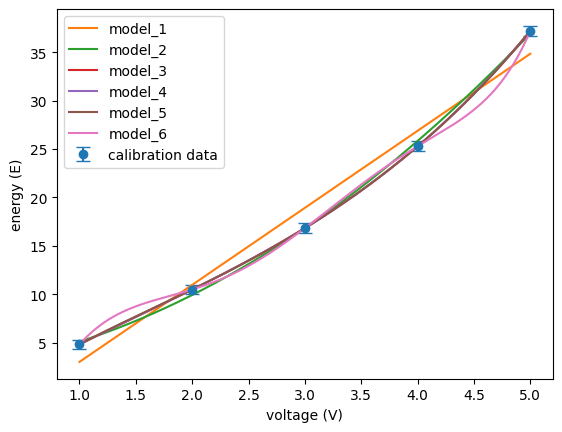

In [7]:

initial_guesses = np.ones (len (models) + 1)
initial_guesses[0] = 0

fig, ax = plt.subplots (nrows = 1, ncols = 1)
ax.errorbar (calib_V, calib_E, yerr=sigma, fmt='o', capsize=5, label = 'calibration data')
ax.set_xlabel ('voltage (V)')
ax.set_ylabel ('energy (E)')

x_axis = np.linspace(1., 5., 1000)
Q_squares = []
N_params = []

for index, model in enumerate (models) :
    least_squares = LeastSquares (calib_V, calib_E, sigma_y, model)
    my_minuit = Minuit (least_squares, *initial_guesses[:index+2])  # starting values
    my_minuit.migrad ()  # finds minimum of least_squares function
#     lista dei parametri
    plot_model (x_axis, model, list (my_minuit.values), ax, 'model_' + str (index+1))
    print ('model_' + str (index+1) + ' --> Q^2 = ' + str (my_minuit.fval))
    Q_squares.append (my_minuit.fval)
    N_params.append (index+2)

ax.legend ()
plt.show ()

## Punto 4

Utilizzando la tecnica dei \textit{toy experiment}, si costruisca l'istogramma della variabile $\Phi$ quando si confronta il modello $\varphi_1$ parabolico con quello $\varphi_2$ cubico, che \`e il caso in cui entrambi descrivono altrettanto bene il campione di calibrazione. Si disegni la corrispondente funzione $F$ sovrapposta all'istogramma, sapendo che \`e definita in \texttt{scipy} come \texttt{scipy.stats.f}, con parametri $df_1 = p_2 - p_1$ e $df_2 = N - p_2$.

In [8]:
from scipy.stats import f as f_pdf

N_toys = 10000

Phi_values = []

df_1 = 4 - 3
df_2 = N_points - 4

for i in range (N_toys) :
    # genera campione
    # fai due fit al campione
    # calcola Phi
    calib_E = [true_model (V) + rand_TCL_ms (0., sigma) for V in calib_V]

    least_squares_3 = LeastSquares (calib_V, calib_E, sigma_y, model_3)
    my_minuit_3 = Minuit (least_squares_3, *initial_guesses[:4])  # starting values
    my_minuit_3.migrad ()  # finds minimum of least_squares function
    if not my_minuit_3.valid : continue
    
    least_squares_2 = LeastSquares (calib_V, calib_E, sigma_y, model_2)
    my_minuit_2 = Minuit (least_squares_2, *initial_guesses[:3])  # starting values
    my_minuit_2.migrad ()  # finds minimum of least_squares function
    if not my_minuit_2.valid : continue

    Phi = ((my_minuit_2.fval - my_minuit_3.fval)/df_1) / (my_minuit_3.fval /df_2)
    Phi_values.append (Phi)

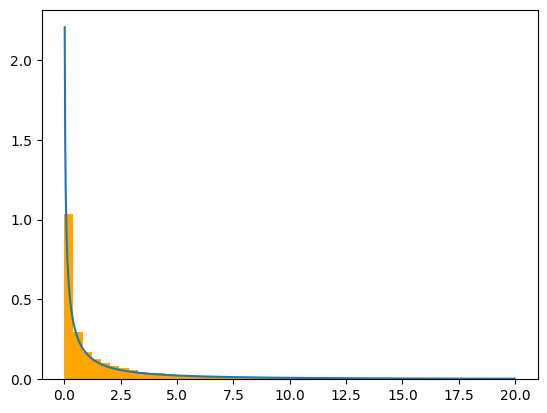

In [9]:
bin_edges = np.linspace (0, 20, 50)
# print ('length of the bin_edges container:', len (bin_edges))
fig, ax = plt.subplots (nrows = 1, ncols = 1)
ax.hist (Phi_values,
         bins = bin_edges,
         color = 'orange',
         density = True
        )

x = np.linspace(0, 20, 1000)
y = f_pdf.pdf (x, dfn = df_1, dfd = df_2)
ax.plot (x,y)

plt.show ()

## Punto 5

Si verifichi che il modello quadratico sia quello corretto utilizzando il test di Fisher-Snedecor: lasciando fissato il campione di calibrazione, si calcoli il \textit{p-value} di compatibilit\`a partendo dal confronto fra un fit lineare e uno parabolico, aumentando via via di una unità l'ordine di entrambi i modelli confrontati.
Quando il \textit{p-value} associato al confronto supera una soglia prestabilita, ad esempio 0.05, il modello con pi\`u parametri viene scartato.

In [10]:

for index in range (len (models) - 1):
    # index --> modello più semplice (polinomio di ordine index+1)
    # index+1 --> modello più sofisticato nel (polinomio di ordine index+2)
    
#    Phi = (Q_squares[index] - Q_squares[index+1]) * (N_points - N_params[index+1]) / (Q_squares[index+1] * (N_params[index+1] - N_params[index]))
#    Phi = (Q_squares[index] - Q_squares[index+1]) * (N_points - N_params[index+1]) / Q_squares[index+1]

    df_1 = N_params[index+1] - N_params[index]
    df_2 = N_points - N_params[index+1]
    if df_2 == 0 : break 

    Phi = ((Q_squares[index] - Q_squares[index+1])/df_1) / (Q_squares[index+1]/df_2)

    p_value = 1. - f_pdf.cdf (Phi, df_1, df_2)
    p_value = f_pdf.sf (Phi, df_1, df_2)   # survival function = 1 - CDF

    print ('model_' + str (index+1) + ' vs. model_' + str (index+2) + ' --> p-value = ' + str (p_value))
    if p_value > 0.05 : 
        print ('model_' + str (index+2) + ' has too many parameters')
        break


model_1 vs. model_2 --> p-value = 0.024879924889028775
model_2 vs. model_3 --> p-value = 0.006558645334412015
